# 4. Валидация и интерпретация модели

Структура раздела:
- 4.1 Загрузка модели и данных
- 4.2 Confusion Matrix
- 4.3 ROC-кривая (сравнение моделей)
- 4.4 Precision-Recall кривая
- 4.5 SHAP — интерпретация предсказаний
- 4.6 Итоговые выводы

## 4.1 Загрузка модели и данных

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Данные
X_test_raw  = pd.read_csv('../data/train_test/X_test_raw.csv')
X_test      = pd.read_csv('../data/train_test/X_test.csv')
X_train_raw = pd.read_csv('../data/train_test/X_train_raw.csv')
X_train     = pd.read_csv('../data/train_test/X_train.csv')
y_test      = pd.read_csv('../data/train_test/y_test.csv').squeeze()
y_train     = pd.read_csv('../data/train_test/y_train.csv').squeeze()

cb_tuned = joblib.load('../models/catboost_model.pkl')
scaler   = joblib.load('../models/scaler.pkl')

# Переобучаем LR для сравнения на ROC-кривой
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Вероятности
cb_probs = cb_tuned.predict_proba(X_test_raw)[:, 1]
lr_probs = lr.predict_proba(X_test)[:, 1]

print("Данные и модели загружены успешно")

Данные и модели загружены успешно


## 4.2 Confusion Matrix

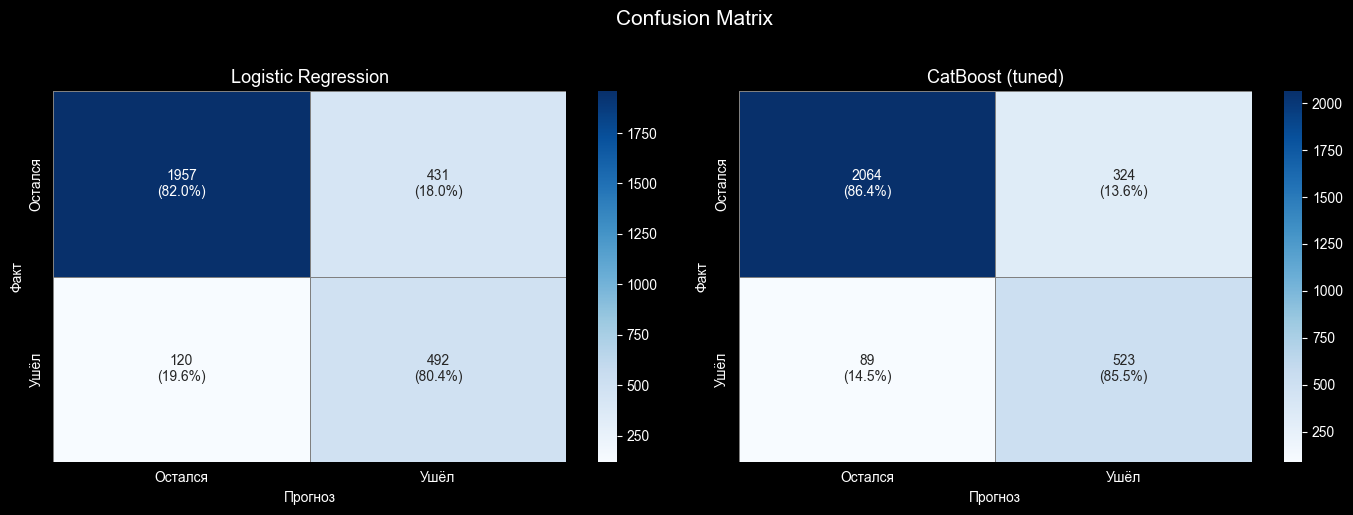

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, name in zip(axes,
                            [lr_probs, cb_probs],
                            ['Logistic Regression', 'CatBoost (tuned)']):
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row, prow)]
                                     for row, prow in zip(cm, cm_pct)]),
                fmt='', cmap='Blues', ax=ax,
                xticklabels=['Остался', 'Ушёл'],
                yticklabels=['Остался', 'Ушёл'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{name}', fontsize=13)
    ax.set_ylabel('Факт')
    ax.set_xlabel('Прогноз')

plt.suptitle('Confusion Matrix', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('graphs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 ROC-кривая и Precision-Recall кривая

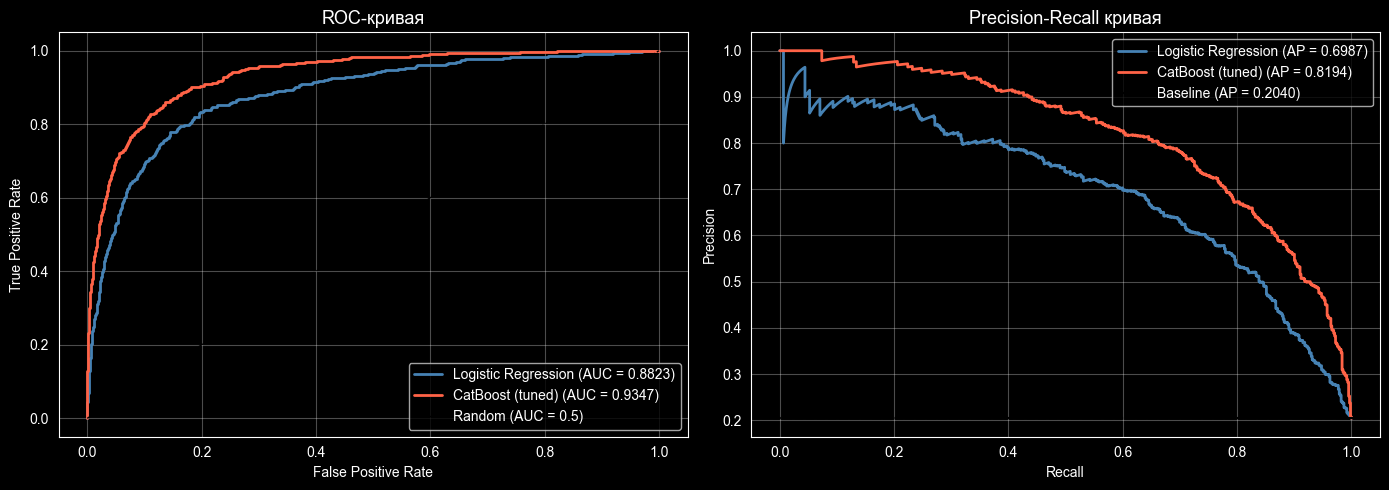

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая ------------------------------------------
for probs, name, color in zip([lr_probs, cb_probs],
                               ['Logistic Regression', 'CatBoost (tuned)'],
                               ['steelblue', 'tomato']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
axes[0].set_title('ROC-кривая', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall кривая ------------------------------------------
for probs, name, color in zip([lr_probs, cb_probs],
                               ['Logistic Regression', 'CatBoost (tuned)'],
                               ['steelblue', 'tomato']):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, color=color, linewidth=2,
                 label=f'{name} (AP = {ap:.4f})')

axes[1].axhline(y_test.mean(), color='black', linestyle='--',
                label=f'Baseline (AP = {y_test.mean():.4f})')
axes[1].set_title('Precision-Recall кривая', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 SHAP — интерпретация модели

SHAP (SHapley Additive exPlanations) объясняет вклад каждого признака
в конкретное предсказание модели. В отличие от feature importance,
SHAP показывает не только *какой* признак важен, но и *как* он влияет —
повышает или снижает вероятность оттока.

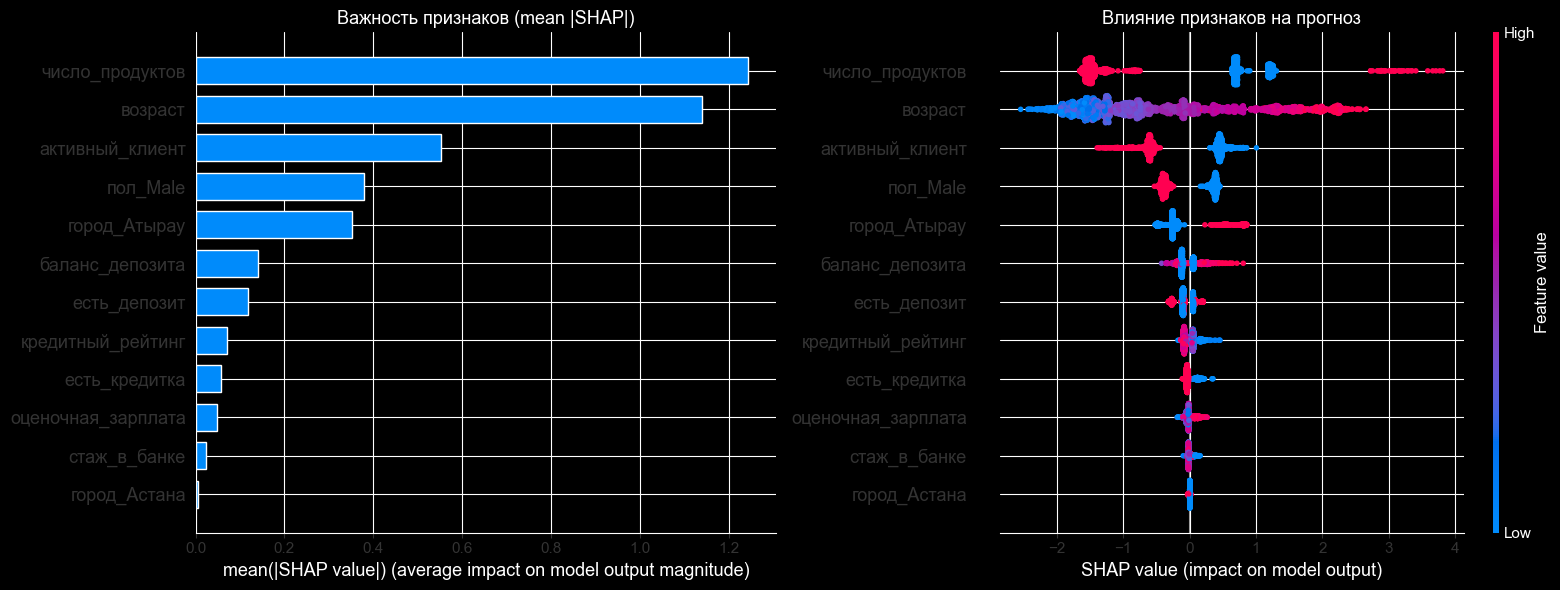

In [15]:
explainer = shap.TreeExplainer(cb_tuned)
shap_values = explainer.shap_values(X_test_raw)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — Bar plot (средняя важность признаков)
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_raw, plot_type='bar',
                  show=False, plot_size=None)
axes[0].set_title('Важность признаков (mean |SHAP|)', fontsize=13)

# График 2 — Beeswarm (направление влияния) (тоже самое что и SHAP, только и по -X)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_raw, show=False, plot_size=None)
axes[1].set_title('Влияние признаков на прогноз', fontsize=13)

plt.tight_layout()
plt.savefig('graphs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Интерпретация SHAP

**Топ признаков по важности:**

- `число_продуктов` — самый важный признак. Beeswarm чётко показывает:
  низкое значение (1 продукт, синий цвет) резко повышает вероятность оттока
  (SHAP уходит вправо до +3-4). Высокое значение (2+ продукта) — снижает риск.

- `возраст` — второй по важности. Высокий возраст (розовый) сдвигает прогноз
  вправо — повышает вероятность оттока. Подтверждает выводы EDA.

- `активный_клиент` — неактивные клиенты (низкое значение, синий)
  показывают отрицательный SHAP — то есть неактивность сильно повышает
  риск ухода.

- `пол_Male` — мужской пол (высокое значение) снижает вероятность оттока,
  что согласуется с EDA: женщины уходят вдвое чаще.

- `город_Атырау` — наличие этого признака (розовый) сдвигает прогноз вправо,
  подтверждая аномально высокий отток в Атырау (42%).

- `стаж_в_банке`, `город_Астана`, `оценочная_зарплата` — минимальный вклад,
  SHAP значения близки к нулю. Признаки малоинформативны для модели,
  что согласуется с корреляционным анализом из раздела 2.4.

**Ключевой портрет клиента группы риска:**
Пожилая женщина из Атырау, неактивный клиент с 1 продуктом и депозитом.

---
## 4.6 Итоговые выводы

### Качество модели
Финальная модель — CatBoost с подобранными гиперпараметрами —
демонстрирует высокое качество на тестовой выборке:

| Метрика    | Значение |
|------------|:--------:|
| ROC-AUC    | 0.9347   |
| F1         | 0.7169   |
| Precision  | 0.6175   |
| Recall     | 0.8546   |
| CV ROC-AUC | 0.9368 ± 0.0043 |

### Интерпретация результатов
Confusion Matrix показывает: из 612 реально ушедших клиентов
модель правильно идентифицирует 523 (85.5%) — это критически важно
для бизнеса, так как пропущенный отток дороже ложной тревоги.

### Портрет клиента группы риска
По совокупности EDA и SHAP-анализа наиболее склонен к уходу клиент:
- **Возраст:** 45+ лет
- **Пол:** женский
- **Город:** Атырау
- **Активность:** неактивный клиент
- **Продукты:** только 1 продукт в банке
- **Депозит:** имеется, но активность низкая

### Рекомендации для бизнеса
- Приоритетная группа для retention-кампаний — неактивные клиенты
  с 1 продуктом старше 45 лет
- Отдельное внимание региону Атырау — отток 42% требует
  локального расследования причин
- Подключение второго продукта значительно снижает риск оттока —
  кросс-продажи как инструмент удержания